# SWIGGY SALES ANALYSIS

## IMPORT LIBRARIES

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
import plotly.express as px

In [4]:
data = pd.read_csv("Downloads/swiggy_data.xlsx - swiggy_data.csv")

### Import Data

In [5]:
data

,State,City,Order Date,Restaurant Name,Location,Category,Dish Name,Price (INR),Rating,Rating Count
0,Karnataka,Bengaluru,6/29/2025,Anand Sweets & Savouries,Rajarajeshwari Nagar,Snack,Butter Murukku-200gm,133.9,4.0,0
1,Karnataka,Bengaluru,4/3/2025,Srinidhi Sagar Deluxe,Kengeri,Recommended,Badam Milk,52.0,4.5,25
2,Karnataka,Bengaluru,1/15/2025,Srinidhi Sagar Deluxe,Kengeri,Recommended,Chow Chow Bath,117.0,4.7,48
3,Karnataka,Bengaluru,4/17/2025,Srinidhi Sagar Deluxe,Kengeri,Recommended,Kesari Bath,65.0,4.6,65
4,Karnataka,Bengaluru,3/13/2025,Srinidhi Sagar Deluxe,Kengeri,Recommended,Mix Raitha,130.0,4.0,0
...,...,...,...,...,...,...,...,...,...,...
197425,Sikkim,Gangtok,1/25/2025,Mama's Kitchen,Gangtok,Momos,Soya cheese chilli momo ...,112.0,4.4,0
197426,Sikkim,Gangtok,7/2/2025,Mama's Kitchen,Gangtok,Momos,Kurkure momo fried ...,140.0,4.4,0
197427,Sikkim,Gangtok,3/25/2025,Mama's Kitchen,Gangtok,Momos,Chilli cheese momo,126.0,4.4,0
197428,Sikkim,Gangtok,3/26/2025,Mama's Kitchen,Gangtok,Momos,Veg Momos (8 Pc),85.0,4.4,0


In [6]:
data.head()

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


,State,City,Order Date,Restaurant Name,Location,Category,Dish Name,Price (INR),Rating,Rating Count
0,Karnataka,Bengaluru,6/29/2025,Anand Sweets & Savouries,Rajarajeshwari Nagar,Snack,Butter Murukku-200gm,133.9,4.0,0
1,Karnataka,Bengaluru,4/3/2025,Srinidhi Sagar Deluxe,Kengeri,Recommended,Badam Milk,52.0,4.5,25
2,Karnataka,Bengaluru,1/15/2025,Srinidhi Sagar Deluxe,Kengeri,Recommended,Chow Chow Bath,117.0,4.7,48
3,Karnataka,Bengaluru,4/17/2025,Srinidhi Sagar Deluxe,Kengeri,Recommended,Kesari Bath,65.0,4.6,65
4,Karnataka,Bengaluru,3/13/2025,Srinidhi Sagar Deluxe,Kengeri,Recommended,Mix Raitha,130.0,4.0,0


In [8]:
data.tail(10)

,State,City,Order Date,Restaurant Name,Location,Category,Dish Name,Price (INR),Rating,Rating Count
197420,Sikkim,Gangtok,2/9/2025,Mama's Kitchen,Gangtok,Momos,Mushroom cheese steam momo ...,112.0,4.4,0
197421,Sikkim,Gangtok,7/28/2025,Mama's Kitchen,Gangtok,Momos,Mushroom cheese fried momo ...,126.0,4.4,0
197422,Sikkim,Gangtok,3/17/2025,Mama's Kitchen,Gangtok,Momos,Mushroom cheese chilli momo ...,140.0,4.4,0
197423,Sikkim,Gangtok,6/18/2025,Mama's Kitchen,Gangtok,Momos,Soya cheese steam momo ...,84.0,4.4,0
197424,Sikkim,Gangtok,8/11/2025,Mama's Kitchen,Gangtok,Momos,Soya cheese fried momo ...,98.0,4.4,0
197425,Sikkim,Gangtok,1/25/2025,Mama's Kitchen,Gangtok,Momos,Soya cheese chilli momo ...,112.0,4.4,0
197426,Sikkim,Gangtok,7/2/2025,Mama's Kitchen,Gangtok,Momos,Kurkure momo fried ...,140.0,4.4,0
197427,Sikkim,Gangtok,3/25/2025,Mama's Kitchen,Gangtok,Momos,Chilli cheese momo,126.0,4.4,0
197428,Sikkim,Gangtok,3/26/2025,Mama's Kitchen,Gangtok,Momos,Veg Momos (8 Pc),85.0,4.4,0
197429,Sikkim,Gangtok,3/27/2025,Mama's Kitchen,Gangtok,Momos,Soya Momo,100.0,4.4,0


### Metadata

In [12]:
print("No of rows",data.shape[0])


No of rows 197430


In [13]:
print("No of fields",data.shape[1])

No of fields 10


In [15]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 197430 entries, 0 to 197429
Data columns (total 10 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   State            197430 non-null  object 
 1   City             197430 non-null  object 
 2   Order Date       197430 non-null  object 
 3   Restaurant Name  197430 non-null  object 
 4   Location         197430 non-null  object 
 5   Category         197430 non-null  object 
 6   Dish Name        197430 non-null  object 
 7   Price (INR)      197430 non-null  float64
 8   Rating           197430 non-null  float64
 9   Rating Count     197430 non-null  int64  
dtypes: float64(2), int64(1), object(7)
memory usage: 15.1+ MB


### Data Types

In [17]:
data.dtypes

State               object
City                object
Order Date          object
Restaurant Name     object
Location            object
Category            object
Dish Name           object
Price (INR)        float64
Rating             float64
Rating Count         int64
dtype: object

In [18]:
data['Order Date'] = pd.to_datetime(data['Order Date'], errors='coerce')

In [19]:
data.dtypes

State                      object
City                       object
Order Date         datetime64[ns]
Restaurant Name            object
Location                   object
Category                   object
Dish Name                  object
Price (INR)               float64
Rating                    float64
Rating Count                int64
dtype: object

In [20]:
data.describe()

,Order Date,Price (INR),Rating,Rating Count
count,197430,197430.000000,197430.000000,197430.000000
mean,2025-05-01 19:41:20.996808960,268.512920,4.341582,28.321805
min,2025-01-01 00:00:00,0.950000,1.500000,0.000000
25%,2025-03-01 00:00:00,139.000000,4.300000,0.000000
50%,2025-05-02 00:00:00,229.000000,4.400000,2.000000
75%,2025-07-01 00:00:00,329.000000,4.500000,15.000000
max,2025-08-31 00:00:00,8000.000000,5.000000,999.000000
std,NaN,219.338363,0.422585,87.542593


## KPI's

### Total sales

In [31]:
total_sales = data["Price (INR)"].sum()
print("Total sales (INR):",round(total_sales,2))

Total sales (INR): 53012505.77


## Average Rating

In [32]:
average_rating = data["Rating"].mean()
print("Average rating:",round(average_rating,1))

Average rating: 4.3


## Average Order Value

In [33]:
Average_order_value = data["Price (INR)"].mean()
print("Average order value:" , round(Average_order_value,2))

Average order value: 268.51


### Rating Count

In [35]:
rating_count = data["Rating Count"].sum()
print("Rating Count:",rating_count)

Rating Count: 5591574


### Total Orders

In [37]:
total_order = len(data)
print("Total Orders:", total_order)

Total Orders: 197430


## Charts Design

### Monthly Sales Trend

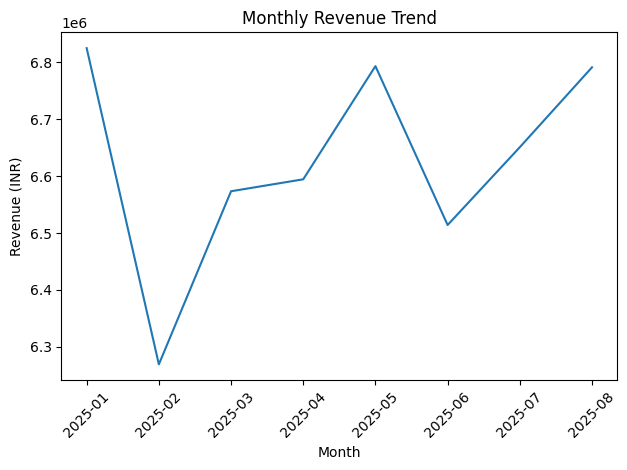

In [41]:
data["Order Date"] = pd.to_datetime(data["Order Date"])

data["YearMonth"] = data["Order Date"].dt.to_period("M").astype(str)

monthly_revenue = data.groupby("YearMonth")["Price (INR)"].sum().reset_index()

plt.figure()
plt.plot(monthly_revenue["YearMonth"], monthly_revenue["Price (INR)"])
plt.xticks(rotation=45)
plt.xlabel("Month")
plt.ylabel("Revenue (INR)")
plt.title("Monthly Revenue Trend")
plt.tight_layout()
plt.show()

## Daily Sales Trend

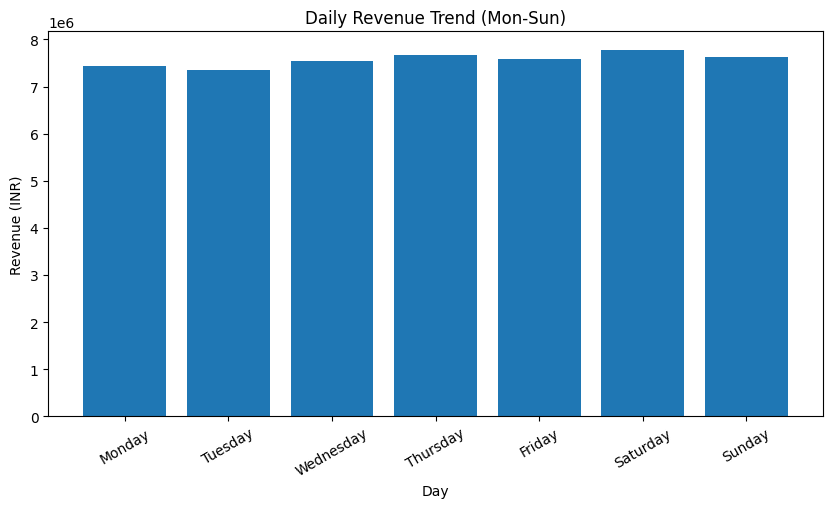

In [42]:
data["DayName"] = pd.to_datetime(data["Order Date"]).dt.day_name()

daily_revenue = (
    data.groupby("DayName")["Price (INR)"]
    .sum()
    .reindex(["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"])
)

plt.figure(figsize=(10,5))
plt.bar(daily_revenue.index, daily_revenue.values)
plt.title("Daily Revenue Trend (Mon-Sun)")
plt.xlabel("Day")
plt.ylabel("Revenue (INR)")
plt.xticks(rotation=30)

plt.show()

### Total Sales by Food Type (Veg vs Non-Veg)

In [43]:
non_veg_keywords = [
    "chicken", "egg", "fish", "mutton",
    "prawn", "biryani", "kabab", "kebab",
    "non-veg", "non veg"
]

data["Food Category"] = np.where(
    data["Dish Name"].str.lower().str.contains("|".join(non_veg_keywords), na=False),
    "Non-Veg",
    "Veg"
)

In [45]:
food_revenue = ( data.groupby("Food Category") ["Price (INR)"] .sum() .reset_index())

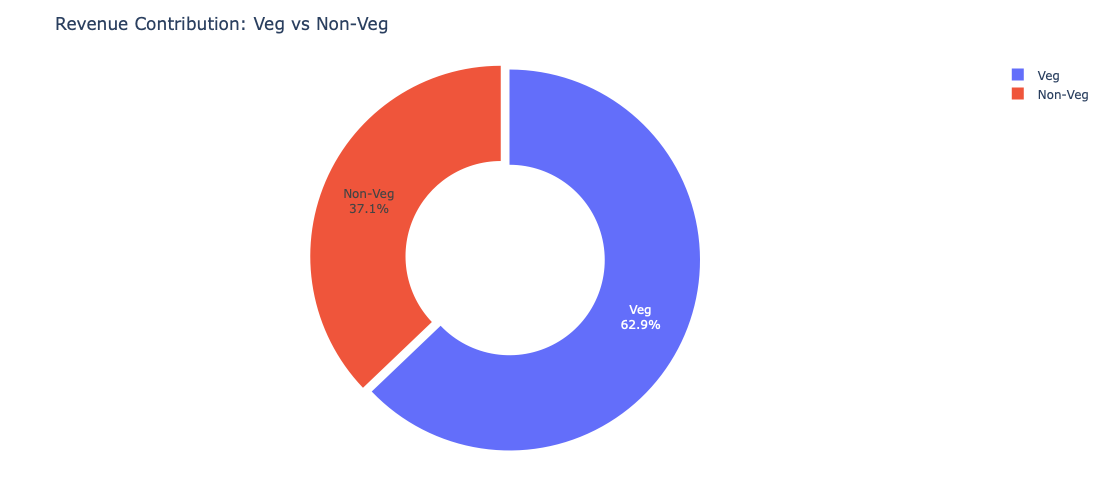

In [46]:
fig = px.pie(
    food_revenue,
    values="Price (INR)",
    names="Food Category",
    hole=0.5,
    title="Revenue Contribution: Veg vs Non-Veg"
)

fig.update_traces(
    textinfo="percent+label",
    pull=[0.05, 0]
)

fig.update_layout(
    height=500,
    margin=dict(t=60, b=40, l=40, r=40)
)

fig.show()

### Total Sales By State

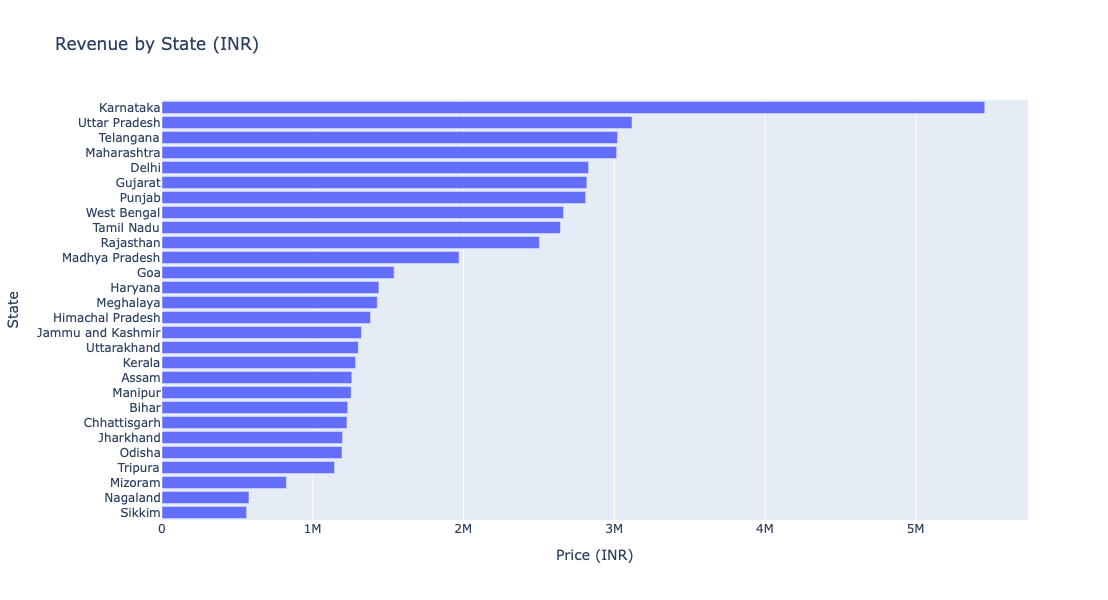

In [47]:
fig = px.bar(
    data.groupby("State", as_index=False)["Price (INR)"].sum()
        .sort_values("Price (INR)", ascending=False),
    x="Price (INR)",
    y="State",
    orientation="h",
    title="Revenue by State (INR)"
)

fig.update_layout(
    height=600,
    yaxis=dict(autorange="reversed")
)

fig.show()

In [48]:
data["Order_Date"] = pd.to_datetime(data["Order Date"])

data["Quarter"] = data["Order_Date"].dt.to_period("Q").astype(str)

quarterly_summary = (
    data.groupby("Quarter", as_index=False)
    .agg(
        Total_Sales=("Price (INR)", "sum"),
        Avg_Rating=("Rating", "mean"),
        Total_Orders=("Order_Date", "count")
    )
    .sort_values("Quarter")
)

quarterly_summary["Total_Sales"] = quarterly_summary["Total_Sales"].round(0)
quarterly_summary["Avg_Rating"] = quarterly_summary["Avg_Rating"].round(2)

quarterly_summary

,Quarter,Total_Sales,Avg_Rating,Total_Orders
0,2025Q1,19667822.0,4.34,73096
1,2025Q2,19902257.0,4.34,74163
2,2025Q3,13442427.0,4.34,50171


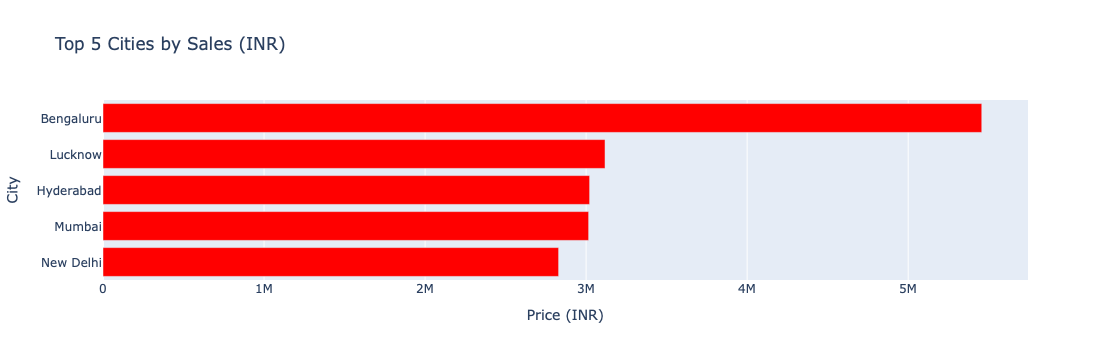

In [49]:
top_5_cities = (
    data.groupby("City")["Price (INR)"]
    .sum()
    .nlargest(5)
    .sort_values()
    .reset_index()
)

fig = px.bar(
    top_5_cities,
    x="Price (INR)",
    y="City",
    orientation="h",
    title="Top 5 Cities by Sales (INR)",
    color_discrete_sequence=["red"]
)

fig.show()